In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/Vradant Sahal/OneDrive/Desktop/Data_Flaw_Hunter/data-flaw-hunter/data/raw/air_quality.csv')

print("Dataset loaded:", df.shape)

Dataset loaded: (29531, 16)


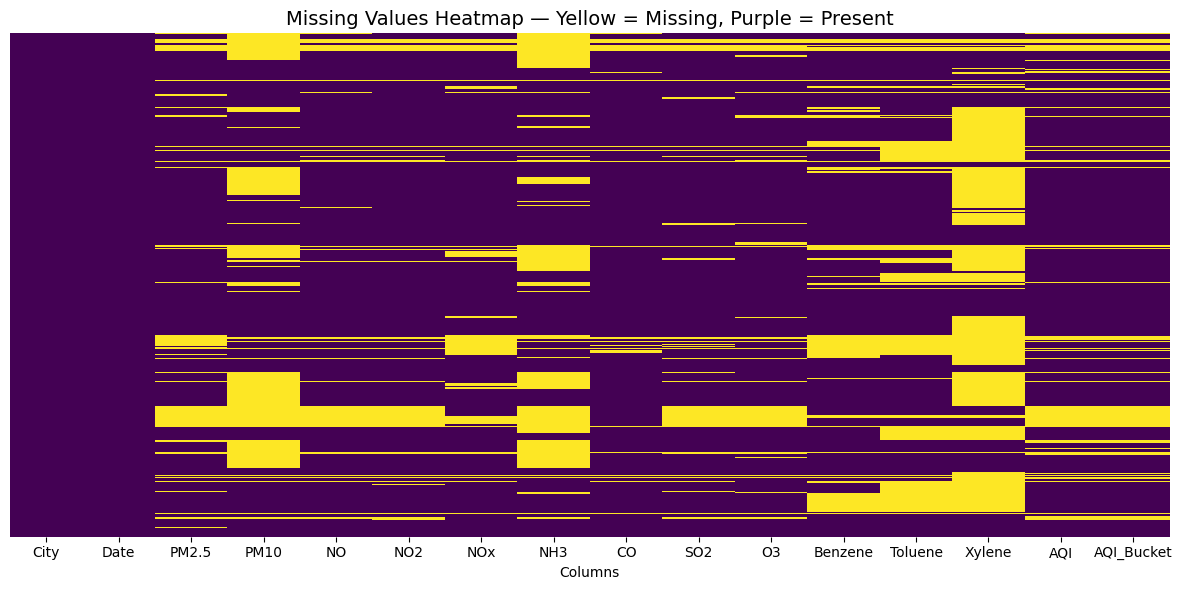

Chart saved!


In [2]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), 
            cbar=False, 
            yticklabels=False,
            cmap='viridis')

plt.title('Missing Values Heatmap — Yellow = Missing, Purple = Present', fontsize=14)
plt.xlabel('Columns')
plt.tight_layout()
plt.savefig('C:/Users/Vradant Sahal/OneDrive/Desktop/Data_Flaw_Hunter/data-flaw-hunter/reports/before_plots/01_missing_heatmap.png', dpi=150)
plt.show()
print("Chart saved!")

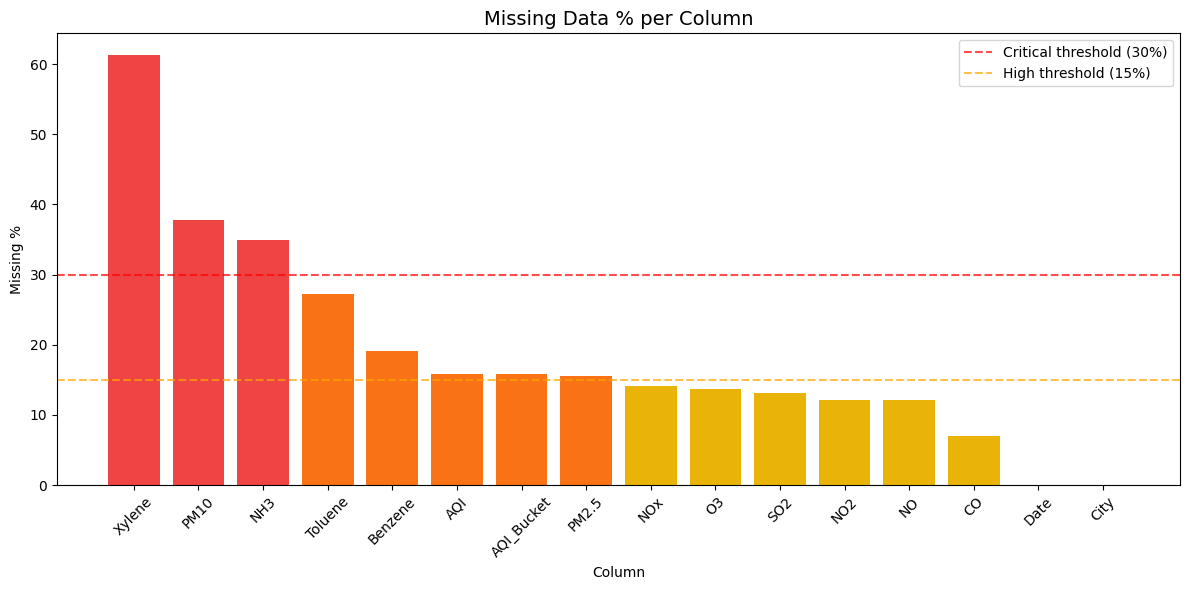

Chart saved!


In [3]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#ef4444' if x > 30 else '#f97316' if x > 15 else '#eab308' for x in missing_pct]
bars = plt.bar(missing_pct.index, missing_pct.values, color=colors)

plt.axhline(y=30, color='red', linestyle='--', alpha=0.7, label='Critical threshold (30%)')
plt.axhline(y=15, color='orange', linestyle='--', alpha=0.7, label='High threshold (15%)')

plt.title('Missing Data % per Column', fontsize=14)
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('C:/Users/Vradant Sahal/OneDrive/Desktop/Data_Flaw_Hunter/data-flaw-hunter/reports/before_plots/02_missing_bar.png', dpi=150)
plt.show()
print("Chart saved!")

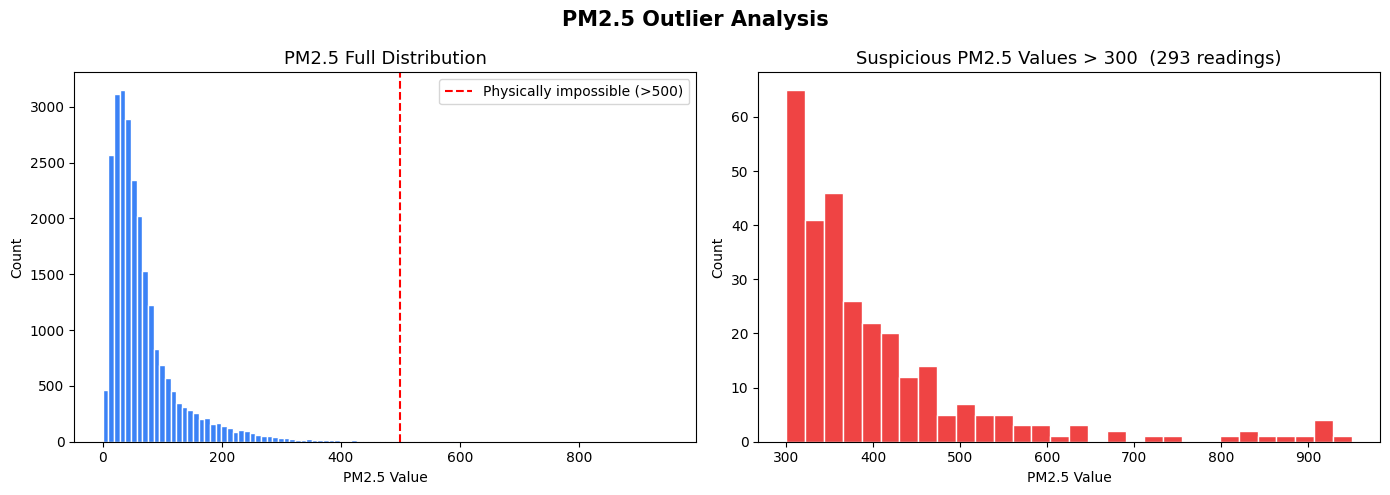

Chart saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution
axes[0].hist(df['PM2.5'].dropna(), bins=100, color='#3b82f6', edgecolor='white')
axes[0].set_title('PM2.5 Full Distribution', fontsize=13)
axes[0].set_xlabel('PM2.5 Value')
axes[0].set_ylabel('Count')
axes[0].axvline(x=500, color='red', linestyle='--', label='Physically impossible (>500)')
axes[0].legend()

# Right: zoomed into suspicious high values
high_pm25 = df[df['PM2.5'] > 300]['PM2.5']
axes[1].hist(high_pm25, bins=30, color='#ef4444', edgecolor='white')
axes[1].set_title(f'Suspicious PM2.5 Values > 300  ({len(high_pm25)} readings)', fontsize=13)
axes[1].set_xlabel('PM2.5 Value')
axes[1].set_ylabel('Count')

plt.suptitle('PM2.5 Outlier Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/Vradant Sahal/OneDrive/Desktop/Data_Flaw_Hunter/data-flaw-hunter/reports/before_plots/03_pm25_outliers.png', dpi=150)
plt.show()
print("Chart saved!")

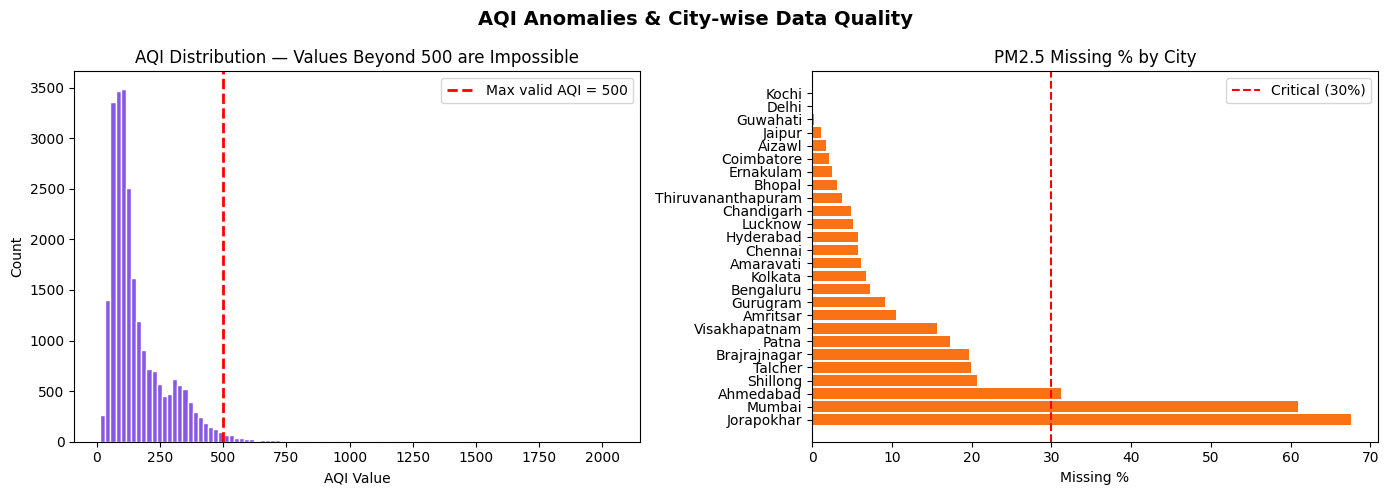

Chart saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: AQI distribution — show the impossible values
axes[0].hist(df['AQI'].dropna(), bins=100, color='#8957e5', edgecolor='white')
axes[0].axvline(x=500, color='red', linestyle='--', linewidth=2, label='Max valid AQI = 500')
axes[0].set_title('AQI Distribution — Values Beyond 500 are Impossible', fontsize=12)
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: missing % per city
city_missing = df.groupby('City')['PM2.5'].apply(lambda x: x.isnull().sum() / len(x) * 100).sort_values(ascending=False)
axes[1].barh(city_missing.index, city_missing.values, color='#f97316')
axes[1].set_title('PM2.5 Missing % by City', fontsize=12)
axes[1].set_xlabel('Missing %')
axes[1].axvline(x=30, color='red', linestyle='--', label='Critical (30%)')
axes[1].legend()

plt.suptitle('AQI Anomalies & City-wise Data Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/Vradant Sahal/OneDrive/Desktop/Data_Flaw_Hunter/data-flaw-hunter/reports/before_plots/04_aqi_city_analysis.png', dpi=150)
plt.show()
print("Chart saved!")